<a href="https://colab.research.google.com/github/vtejaswini66/AI-ML-PROJECTS-5/blob/main/STOCK_PREDICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("stock_sample_dataset.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-01,150,155,148,154,154,1000000
1,2024-01-02,152,157,150,156,156,1050000
2,2024-01-03,154,159,152,158,158,1100000
3,2024-01-04,156,161,154,160,160,1150000
4,2024-01-05,158,163,156,162,162,1200000


In [4]:
data = df[['Close']]

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [6]:
import numpy as np

X = []
y = []

for i in range(5, len(scaled_data)):
    X.append(scaled_data[i-5:i, 0])  # last 5 days
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [7]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X, y, epochs=10, batch_size=4)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3728
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2304 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1248 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0537 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 


In [9]:
predictions = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


In [10]:
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y.reshape(-1,1))

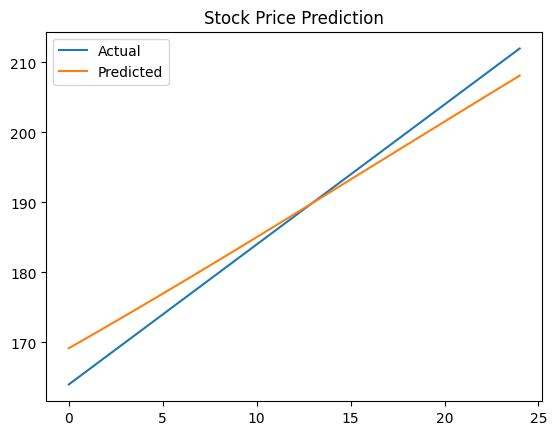

In [11]:
import matplotlib.pyplot as plt

plt.plot(actual, label='Actual')
plt.plot(predictions, label='Predicted')

plt.legend()
plt.title("Stock Price Prediction")

plt.show()

In [12]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [13]:
# Take last 5 days from dataset
last_5_days = scaled_data[-5:]

# Reshape for model
last_5_days = last_5_days.reshape(1, 5, 1)

# Predict next day
next_day_scaled = model.predict(last_5_days)

# Convert back to real value
next_day_price = scaler.inverse_transform(next_day_scaled)

print("Next Day Predicted Price:", next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Next Day Predicted Price: 209.74901


In [14]:
from sklearn.metrics import r2_score

# Convert predictions and actual back to same shape
r2 = r2_score(actual, predictions)

print("R2 Score (Accuracy):", r2)

R2 Score (Accuracy): 0.9649446129892917


In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual, predictions))

print("RMSE:", rmse)

RMSE: 2.700281559065152


In [16]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ===== NEXT DAY PREDICTION =====
last_5_days = scaled_data[-5:]
last_5_days = last_5_days.reshape(1, 5, 1)

next_day_scaled = model.predict(last_5_days)
next_day_price = scaler.inverse_transform(next_day_scaled)

# ===== MODEL PERFORMANCE =====
r2 = r2_score(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

# ===== FINAL OUTPUT =====
print("=========== FINAL OUTPUT ===========")
print("Next Day Predicted Price:", round(next_day_price[0][0], 2))
print("R2 Score:", round(r2, 2))
print("RMSE:", round(rmse, 2))
print("===================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
=========== FINAL OUTPUT ===========
Next Day Predicted Price: 209.75
R2 Score: 0.96
RMSE: 2.7
